# OVERVIEW
This notebooks as acts as an example of how to use associated src python files

In [1]:
import sys
sys.path.append('../src')
sys.path.append('../../past_market_analysis/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import fetch_price_data
from analysis import compute_returns, summary_statistics
from arima_model import test_stationary, find_best_arima_model, fit_arima
from garch_model import fit_garch, forecast_volatility, backtest_garch, fit_asymmetric_garch, compare_garch_vs_implied, cross_ticker_validation
from plotting import plot_garch_forecast

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


We start with the ADF stationary test, which is a statistical test to whether a given quantity depends on time or not. Quantities primarily include close prices and returns. 

In [2]:
ticker = "AAPL"
df = fetch_price_data(ticker, period="3y")
df = compute_returns(df)

test_stationary(df['Close'], label=f"{ticker} raw price") #testing whether the raw price depends on time
print()
test_stationary(df['Return'], label=f"{ticker} returns") #testing whether returns depend on time

[*********************100%***********************]  1 of 1 completed

ADF test - AAPL raw price
Test statistic - -0.6136
p-value - 0.8679
Stationary? No

ADF test - AAPL returns
Test statistic - -13.5930
p-value - 0.0000
Stationary? Yes


np.True_

We see that the close prices are time-dependent, which makes sense as the close price of a ticker generally trend over time, but the individual returns day to day have no time dependence at all. This leads into the next topic, the ARIMA (AutoRegressive Integreated Moving Average) model which choose parameters (p, d, q), p being how many previous days values todays values depends on, d being the number of times to difference to make time independent (by above for returns, d=0, close prices d=1) and q being the number of recent days errors todays price depends on.

In [3]:
model = fit_arima(df['Return'])
print(model.summary())

Best order: (1, 0, 3) (AIC = -3993.84)
                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                  752
Model:                 ARIMA(1, 0, 3)   Log Likelihood                2003.324
Date:                Sun, 02 Aug 2026   AIC                          -3994.647
Time:                        00:00:24   BIC                          -3966.911
Sample:                             0   HQIC                         -3983.961
                                - 752                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.001      1.432      0.152      -0.000       0.002
ar.L1          0.7216      0.162      4.447      0.000       0.404       1.040
ma.L1        

We are looking at the returns of apple, so expect d=0. p=1, q=3 tell us that todays price depends yesterdays price and the last 3 days of forecast errors. We now look at GARCH (Generalised AutoRegressive Conditional Heteroskedasticity), which does a similar thing, but for the volatility of a ticker instead and by fixing the number of days to be 1 (only look at yesterdays volatility and forecast volatility error) and look for suitable coefficients that fit.

In [4]:
garch_fitted = fit_garch(df['Return'])
print(garch_fitted.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1416.10
Distribution:                  Normal   AIC:                           2840.21
Method:            Maximum Likelihood   BIC:                           2858.70
                                        No. Observations:                  752
Date:                Sun, Aug 02 2026   Df Residuals:                      751
Time:                        00:00:24   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0755  5.674e-02      1.331      0.183 [-3.56

The expected relationship is: 
$$
\sigma_{t}^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2
$$
after choosing p = q = 1. the sum $ \alpha + \beta $ measures the persistency of volatility shocks (since $\alpha$ measures how much yesterdays shocks affect the volatility of today, and $\beta$ measures how much yesterdays volatility affects today volatility). If $ \alpha + \beta < 1 $ then we conclude that eventually, volatilty shocks returns back to normal, however the closer to 1, the longer that process takes. If $ \alpha + \beta \geq 1 $, then volatility shocks may never truly fade, a case called integrated GARCH. We notice that a big shock will still affect a tickers volatility weeks later, here modelled by a chain process decreasing each day

We also see from a statistical analysis perspective that beta is very statistically significant, whereas omega, alpha are quite insignificant. Notice in the mean model, our p-value is just about insignificant, so the model is not finding evidence of a non-zero average return, although this value is very close to our significance level. We now forecast volatility for future days using these coefficients

In [5]:
garch_fitted = fit_garch(df['Return'])
vol_forecast = forecast_volatility(garch_fitted, horizon=10)

stats = summary_statistics(df)
print(f"Historical realised volatility: {stats['annualised_vol']:.4f} ({stats['annualised_vol']*100:.2f}%)")
print()
print("Garch volatility forecast (annualised):")
for day, vol in enumerate(vol_forecast, 1):
    print(f"Day {day}: {vol:.4f} ({vol*100:.2f}%)")

Historical realised volatility: 0.2702 (27.02%)

Garch volatility forecast (annualised):
Day 1: 0.4082 (40.82%)
Day 2: 0.4019 (40.19%)
Day 3: 0.3958 (39.58%)
Day 4: 0.3900 (39.00%)
Day 5: 0.3844 (38.44%)
Day 6: 0.3790 (37.90%)
Day 7: 0.3739 (37.39%)
Day 8: 0.3690 (36.90%)
Day 9: 0.3642 (36.42%)
Day 10: 0.3597 (35.97%)


We see over time, the GARCH model forecasts the volatility to return to its historically realised level, we below plot the GARCH forecast against the 10, 30 day rolling volatility with the historic realised volatility as a baseline

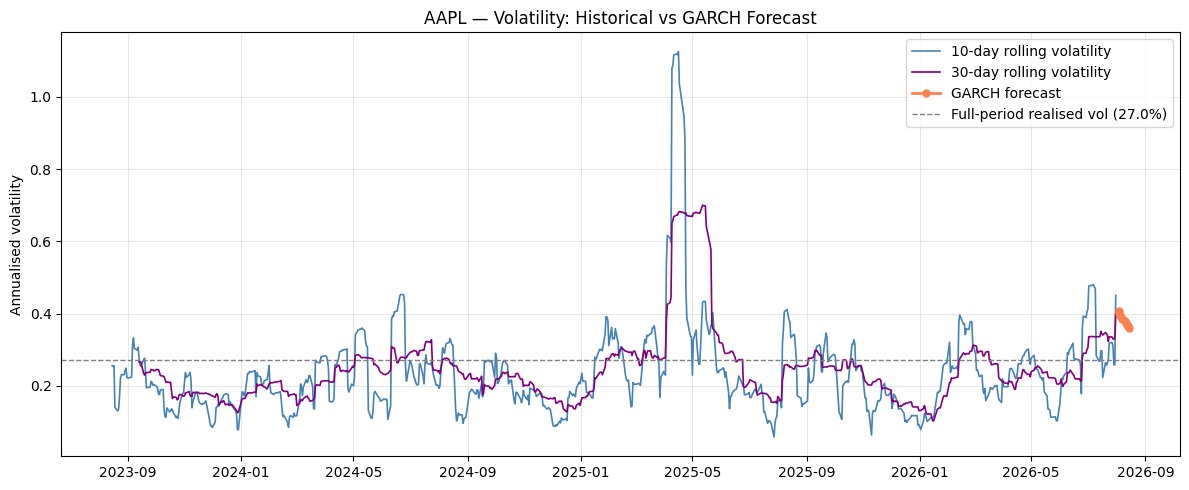

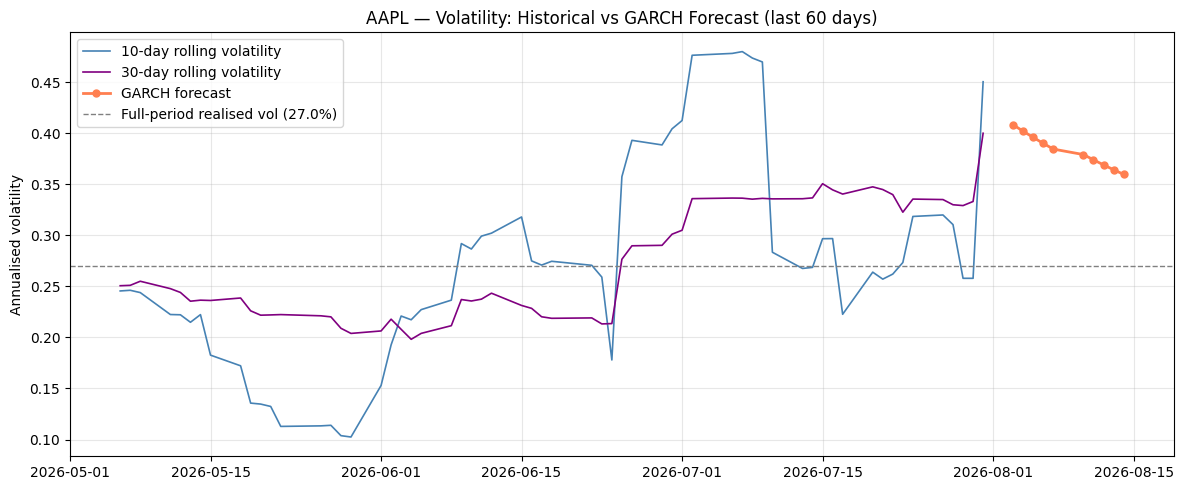

In [6]:
plot_garch_forecast(df, vol_forecast, stats['annualised_vol'], ticker)
plot_garch_forecast(df, vol_forecast, stats['annualised_vol'], ticker, zoom_days=60)

We can see better in the zoomed plot that the GARCH forecast sits roughly in between the 10, 30 day rolling averages, which makes sense, as the blue line is wild (full recency bias), the purple signal smoothes this out, so the future forecast should be somewhere in between. We now look at backtesting our GARCH model over the history of the tickers lifespan.

In [7]:
bt = backtest_garch(df['Return'], train_size=500, refit_every=5)

#we look at different metrics of measuring error
mae = (bt['predicted_vol'] - bt['actual_vol']).abs().mean()
rmse = np.sqrt(((bt['predicted_vol'] - bt['actual_vol'])**2).mean())
corr = bt['predicted_vol'].corr(bt['actual_vol'])

print(f"Backtest observations: {len(bt)}")
print(f"Mean absolute error:   {mae:.4f}")
print(f"RMSE:                  {rmse:.4f}")
print(f"Correlation:           {corr:.4f}")

Backtest observations: 231
Mean absolute error:   0.0612
RMSE:                  0.0727
Correlation:           0.0621


We see the GARCH model is not particularly similar or correlated to the actual volatility. This tells us that predicting future volatility isn't particularly correlated to looking at previous history. We now compare with the implied volatility of the market from the options_pricing project, where the implied volatility is calculated using a real life option and working backwards to find what the volatility must've been.

In [8]:
result = compare_garch_vs_implied("AAPL", expiry_index=5)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Ticker:              AAPL
Current price:       $308.91
Strike used:         $310.00
Expiry:              2026-08-28 (T=0.0712 years)
Option lastPrice:    $8.90  (not a live quote, see options_pricing README)
Implied volatility:  0.2705 (27.05%)
Realised volatility: 0.2585 (25.85%)
Difference:          1.19 percentage points

--- AAPL volatility comparison ---
Realised (historical):  0.2585 (25.85%)
GARCH forecast:         0.4064 (40.64%)
Implied (market):       0.2705 (27.05%)
Implied - GARCH:        -13.59 pp


We see that the GARCH forecast is predicting a period of higher volatility compared volatility implied by options pricing, so investors are predicting AAPL's volatility to return to historical levels. We now continue to looking at asymmetric GARCH. The first of which is GJR-GARCH which adds a term which only applies for negative shocks that occured in the previous day. This coefficent is called $\gamma$. fit_asymmetric_garch also has model_type='EGARCH' feature, which models the EGARCH, where we model log variance instead.

In [9]:
gjr = fit_asymmetric_garch(df['Return'], model_type='GJR')
print(gjr.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -1405.53
Distribution:                  Normal   AIC:                           2821.06
Method:            Maximum Likelihood   BIC:                           2844.18
                                        No. Observations:                  752
Date:                Sun, Aug 02 2026   Df Residuals:                      751
Time:                        00:00:26   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0581  5.476e-02      1.062      0.288 [-4.91

We see that in our example, recall from normal GARCH that $\alpha =0.07$ and here we have $ (\alpha, \gamma) = (0.0018, 0.128)$, so most of the volatilty modelled is negative and the $\alpha$ before was almost an average of our now $\alpha$ and $\gamma$. 

In [10]:
plain = fit_garch(df['Return'])
gjr = fit_asymmetric_garch(df['Return'], model_type='GJR')

print(f"Plain GARCH AIC: {plain.aic:.2f}")
print(f"GJR-GARCH AIC:   {gjr.aic:.2f}")
print(f"Improvement:     {plain.aic - gjr.aic:.2f}")

Plain GARCH AIC: 2840.21
GJR-GARCH AIC:   2821.06
Improvement:     19.14


We see here that GJR-GARCH provides a more accurate forecasting of AAPL's volatility than GARCH when using AIC to measure. We end by comparing the above models across a variety of tickers to see what we can conclude.

In [11]:
tickers = ["AAPL", "NVDA", "SPY", "JNJ", "TSLA"]
summary = cross_ticker_validation(tickers, period="3y")
summary


Processing AAPL


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Best order: (1, 0, 3) (AIC = -3993.84)

Processing NVDA


Best order: (1, 0, 0) (AIC = -3156.49)

Processing SPY


[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed


Best order: (3, 0, 2) (AIC = -4618.91)

Processing TSLA


[*********************100%***********************]  1 of 1 completed


Best order: (0, 0, 0) (AIC = -2827.58)


,ARIMA_order,GARCH_alpha_beta,GJR_gamma,GJR_gamma_pval,AIC_improvement
Ticker,,,,,
AAPL,"(1, 0, 3)",0.9463,0.1279,0.0150,19.14
NVDA,"(1, 0, 0)",0.9597,0.2668,0.0732,20.81
SPY,"(0, 0, 3)",0.9244,0.1807,0.6388,48.33
JNJ,"(3, 0, 2)",0.7623,-0.0164,0.8772,-1.93
TSLA,"(0, 0, 0)",0.9895,0.0282,0.1582,2.83


We see for all tickers but JNJ tested that GJR-GARCH provided a better forecasting of the volatility, and even in the JNJ example, the value of $\gamma$ is very insignicant. The ARIMA orders follow no strict correlation from ticker to ticker, showing that it is an individual ticker model not a general market model. $\alpha + \beta$ is very close to one for all tickers apart from JNJ, implying that periods of high volatility continue for longer periods of time, and take longer to return to a base rate.